# Tutorial 1: Merge Multi-ROI Chromatin Trace Data

This tutorial walks through the standard workflow for merging chromatin tracing data from multiple regions of interest (ROIs):

1. **Collect** trace files from all ROIs into one folder
2. **Assess quality** by computing Pearson correlations between ROIs
3. **Remove** ROIs with poor correlation (outliers)
4. **Re-assess** the correlation matrix after removal
5. **Merge** the remaining trace files into a single table
6. **Statistics** on the merged dataset
7. **Next steps** — link to Tutorial 2 for quality control

## Step 0: Set-up your data and output path

In [36]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg



Set up your folder data path:

In [37]:
data_path = "/home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center"

Set up destination folder for output:


In [38]:
dest_path = f"{data_path}/output"

Check ROIs detected:

In [39]:
print(f"Data path: {data_path}")
print(f"Output path: {dest_path}")
print(f"\nAvailable ROIs:")
for d in sorted(Path(data_path).iterdir()):
    if d.is_dir() and "ROI" in d.name:
        print(f"  {d.name}")

Data path: /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center
Output path: /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output

Available ROIs:
  018_ROI
  021_ROI
  022_ROI
  023_ROI
  024_ROI
  025_ROI
  029_ROI
  031_ROI


## Step 1: Collect trace files from all ROIs

`collect_files` scans each subdirectory of `--root` for a file matching `--example-file`.
The `--variable-part "13"` indicates that the ROI number varies; fixed-length matching naturally excludes Matrix files (different filename length).

In [45]:
!collect_files --root {data_path} --example-file "Trace_3D_barcode_mask-mask0_ROI-18_Pdx1_filtered_Pdx1.ecsv" --variable-part "18" --copy-to {dest_path}/raw_traces --force

Matched (8):
  018_ROI -> /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/018_ROI/Trace_3D_barcode_mask-mask0_ROI-18_Pdx1_filtered_Pdx1.ecsv
  021_ROI -> /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/021_ROI/Trace_3D_barcode_mask-mask0_ROI-21_Pdx1_filtered_Pdx1.ecsv
  022_ROI -> /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/022_ROI/Trace_3D_barcode_mask-mask0_ROI-22_Pdx1_filtered_Pdx1.ecsv
  023_ROI -> /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/023_ROI/Trace_3D_barcode_mask-mask0_ROI-23_Pdx1_filtered_Pdx1.ecsv
  024_ROI -> /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/024_ROI/Trace_3D_barcode_mask-mask0_ROI-24_Pdx1_filtered_Pdx1.ecsv
  025_ROI -> /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/025_ROI/Trace_3D_barcode_mask-mask0_ROI-25_Pdx1_filtered_Pdx1.ecsv
  0

## Step 2: Compute Pearson correlations between ROIs

`trace_pearsons` computes a pairwise distance map for each ROI (median 3D distance between every barcode pair), then calculates the Pearson correlation between these maps.

A high correlation between two ROIs means they share similar chromatin organization. An ROI with low correlation against all others is likely an outlier (imaging artifact, poor segmentation, etc.).

Analyzing 8 trace files...
Processing Trace_3D_barcode_mask-mask0_ROI-18_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-21_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-22_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-23_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-24_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-25_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-29_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-31_Pdx1_filtered_Pdx1.ecsv
$ Saved correlation matrix as /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/trace_correlation_matrix.png
$ Saved correlation matrix data in NPY format: /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/trace_correlation_matrix.npy


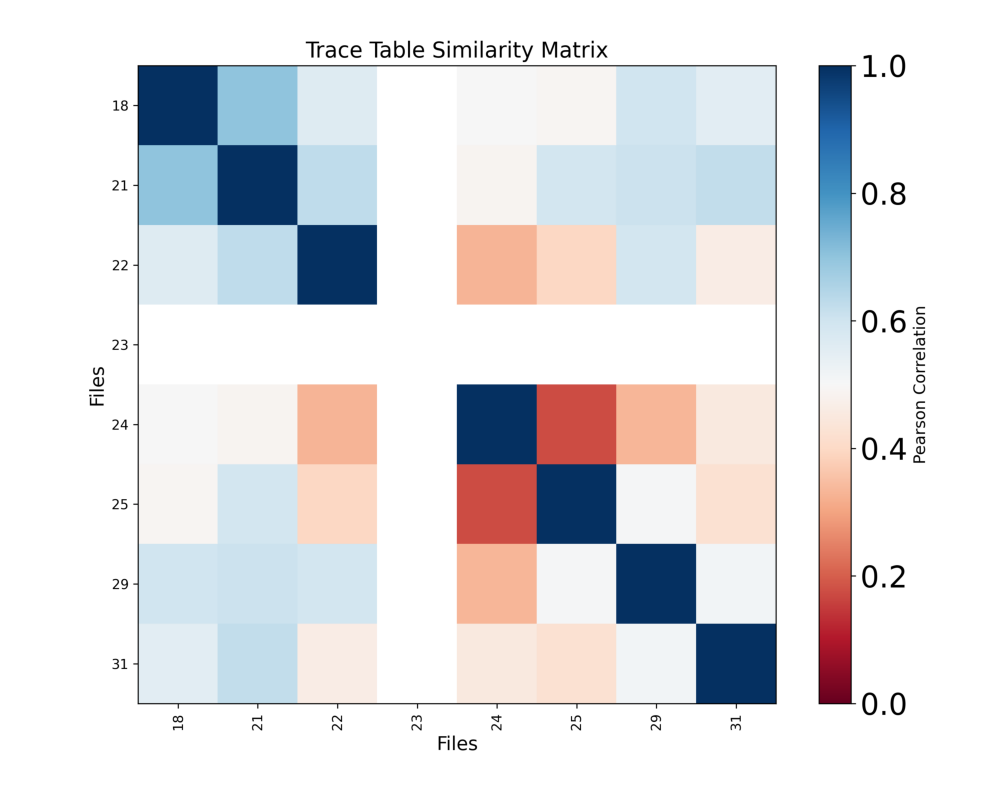

In [46]:
!ls {dest_path}/raw_traces/*.ecsv | trace_pearsons --pipe -O {dest_path}

# Display the correlation matrix
img = mpimg.imread(f"{dest_path}/trace_correlation_matrix.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Remove poorly-correlated ROIs

For each ROI, we compute its **mean Pearson correlation** with all other ROIs. ROIs below the threshold are removed from the working folder before merging.

A threshold of **0.70** is conservative: it removes only clear outliers while preserving the vast majority of the data.

In [47]:
# Load the correlation matrix saved by trace_pearsons
corr = np.load(f"{dest_path}/trace_correlation_matrix.npy")
traces = sorted(Path(f"{dest_path}/raw_traces").glob("*.ecsv"))

# Mean correlation per ROI (exclude self-correlation on the diagonal)
np.fill_diagonal(corr, np.nan)
mean_corr = np.nanmean(corr, axis=1)

# Remove ROIs below threshold
threshold = 0.40
for trace, mc in zip(traces, mean_corr):
    if mc < threshold or np.isnan(mc):
        trace.unlink()
        print(f"Removed {trace.name}  (mean Pearson = {mc:.3f})")
    else:
        print(f"Kept    {trace.name}  (mean Pearson = {mc:.3f})")

Kept    Trace_3D_barcode_mask-mask0_ROI-18_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.568)
Kept    Trace_3D_barcode_mask-mask0_ROI-21_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.606)
Kept    Trace_3D_barcode_mask-mask0_ROI-22_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.495)
Removed Trace_3D_barcode_mask-mask0_ROI-23_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = nan)
Removed Trace_3D_barcode_mask-mask0_ROI-24_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.379)
Kept    Trace_3D_barcode_mask-mask0_ROI-25_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.430)
Kept    Trace_3D_barcode_mask-mask0_ROI-29_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.525)
Kept    Trace_3D_barcode_mask-mask0_ROI-31_Pdx1_filtered_Pdx1.ecsv  (mean Pearson = 0.504)


/tmp/ipykernel_33198/3729395962.py:7: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(corr, axis=1)


## Step 4: Re-run Pearson to verify improvement

After removing the outlier ROIs, the correlation matrix should show higher overall values.

Analyzing 6 trace files...
Processing Trace_3D_barcode_mask-mask0_ROI-18_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-21_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-22_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-25_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-29_Pdx1_filtered_Pdx1.ecsv
Processing Trace_3D_barcode_mask-mask0_ROI-31_Pdx1_filtered_Pdx1.ecsv
$ Saved correlation matrix as /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/trace_correlation_matrix.png
$ Saved correlation matrix data in NPY format: /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/trace_correlation_matrix.npy


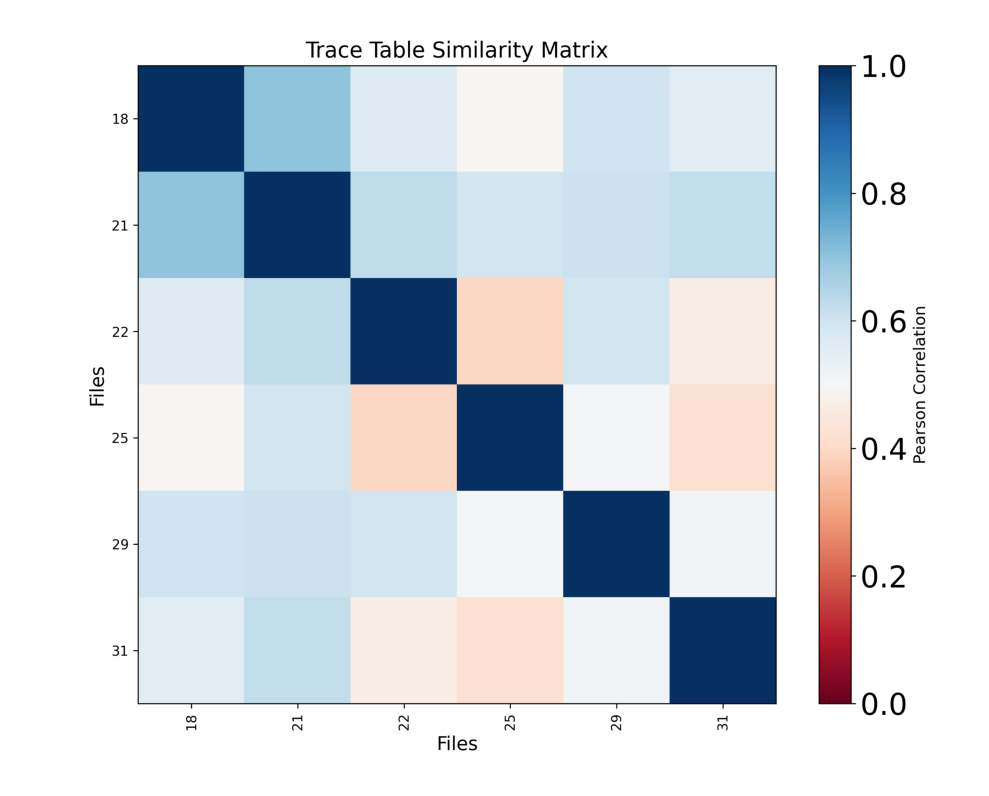

In [48]:
!ls {dest_path}/raw_traces/*.ecsv | trace_pearsons --pipe -O {dest_path}

# Display the updated correlation matrix
img = mpimg.imread(f"{dest_path}/trace_correlation_matrix.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Merge trace files

In [49]:
!ls {dest_path}/raw_traces/*.ecsv | trace_merge -F {dest_path} -N merged_traces.ecsv

Number of trace files to merge: 6
 $ Merged trace file will contain 16217 traces
Read and accumulated 6 trace files
$ Saving output table as /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/merged_traces.ecsv ...
Finished execution


## Step 6: Compute basic statistics

In [50]:
!trace_stats --input {dest_path}/merged_traces.ecsv

$ Importing table from pyHiM format
Successfully loaded trace table: /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/merged_traces.ecsv
Statistics for /home/xdevos/Documents/traceratops/data_for_xavier_PDX1/data_for_xavier/Pdx1/Center/output/merged_traces.ecsv:
- Number of unique ROIs: 6
- Number of unique chromatin traces: 1669
- Number of unique barcodes: 23


## Next steps

The merged trace file is ready for downstream analysis.

Continue with **Tutorial 2 — Quality Control** to:
- Generate detailed quality metrics with `trace_analyzer`
- Interpret barcode detection, neighbor distances, and barcode frequency plots
- Decide on filtering thresholds for Tutorial 3

## Summary

| Step | Script | Output |
|------|--------|--------|
| Collect | `collect_files` | `raw_traces/` (one .ecsv per ROI) |
| Correlations | `trace_pearsons` | `trace_correlation_matrix.png` + `.npy` |
| Filter ROIs | Python (numpy) | removed outlier files from `raw_traces/` |
| Merge | `trace_merge` | `merged_traces.ecsv` |
| Statistics | `trace_stats` | stdout |

**Output location:** `data/output/`